# Seasonal Agriculture Performance Analysis

**Major Project – Data Analytics**

**Domain:**   Agriculture and Agricultural Analytics

**Project Theme:** Seasonal Agricultural Performance Analysis

**Tools & Technologies:** Python, Pandas, NumPy, Matplotlib, Seaborn, Google Colab

## Project Goal

The primary goal of this project is to conduct a comprehensive data-driven analysis of agricultural performance across different seasons. The project aims to examine seasonal variations, identify significant patterns and trends, analyze relationships among relevant agricultural factors, and evaluate differences in performance using appropriate statistical and visualization techniques.

The analysis will be based entirely on the available agricultural dataset. Various data analytics methods will be applied to transform raw data into meaningful insights that can support a better understanding of seasonal agricultural performance.

This project focuses on Data Analytics. It does not involve Machine Learning model development or dashboard development.

**1. Problem Statement**

Agricultural performance is influenced by several factors, including seasonal climatic conditions, cultivation practices, availability of agricultural resources, crop characteristics, and economic conditions. These factors can lead to considerable variations in agricultural outcomes across different seasons.

However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions.The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.


**2. Project Objectives**

* **Understand the structure and quality** of the agricultural dataset.

* **Clean and prepare the data** to ensure it is suitable for reliable analysis.

*  **Analyze seasonal patterns and variations** in agricultural performance.

*  **Perform descriptive and statistical analysis** to summarize and interpret the data.

* **Examine relationships between relevant variables** and identify meaningful associations.

*  **Compare agricultural performance** across different seasons and other relevant categories.

*  **Create appropriate visualizations** using univariate, bivariate, and multivariate analysis techniques.

* **Identify important patterns, trends, and findings** from the analyzed data.

* **Develop evidence-based insights and recommendations** based on the results of the analysis.


**3. Dataset**

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

Dataset file: seasonal_agriculture_performance_dataset.csv

In [1]:
#Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
#Load the dataset

file_path="/content/seasonal_agriculture_performance_dataset.csv"
df=pd.read_csv(file_path)

print("Dataset loaded successfully")

Dataset loaded successfully


**4. Dataset Overview and Understanding**

In [4]:
#To know Dataset shape

df.shape

(4000, 28)

In [5]:
# First  5 rows

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [6]:
# Last 5 rows
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [7]:
# Random sample of records

df.sample(3, random_state=11)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3198,SF13199,Andhra Pradesh,Nalgonda,Groundnut,Rabi,6.99,511.80,25.20,50.80,6.60,7.14,29.00,159.40,52.10,114.70,Flood,238.90,4.81,0.66,1.65,11.53,58301,451491,672211,220720,4337,2.66,41.90
1392,SF11393,Karnataka,Nashik,Chilli,Kharif,2.36,784.70,30.60,56.90,5.90,5.26,27.80,95.80,35.20,112.60,Drip,196.10,9.34,0.89,0.30,0.71,100437,171687,71310,-100377,1274,0.56,27.40
637,SF10638,Tamil Nadu,Indore,Chilli,Rabi,12.79,560.50,17.70,51.80,6.20,5.20,19.50,130.50,66.50,89.10,Sprinkler,191.00,5.59,0.68,0.30,3.84,92541,979377,355357,-624020,7081,0.54,35.90


In [11]:
#To display column names
display(df.columns.to_list())

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [13]:
# To get dataset info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [15]:
# To get Statistical information about dataset

df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [16]:
# Categorical Summary

df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


**5. Data Quality Analysis**

Before conducting detailed analysis, the dataset will be systematically assessed for missing values, duplicate records, data types, inconsistencies, and unusual or abnormal values. This process ensures that the data is accurate, consistent, and reliable for further analysis.

In [23]:
# Missing values

missing_values=df.isnull().sum().sort_values(ascending=False)
missing_values


,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


In [37]:
from pandas.core.dtypes import missing
# missing_percentage

missing_percentage=(missing_values/len(df))*100
missing_percentage

,0
Rainfall_mm,1.20
Soil_Moisture_pct,1.00
Yield_Tonnes_Ha,0.80
Farm_ID,0.00
Crop,0.00
District,0.00
Farm_Area_Hectares,0.00
Season,0.00
Avg_Temperature_C,0.00
Humidity_pct,0.00


In [44]:
# View in dataframe
missing_Summary = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage": missing_percentage
})

missing_Summary[missing_Summary['Missing Count']>0]

,Missing Count,Missing Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


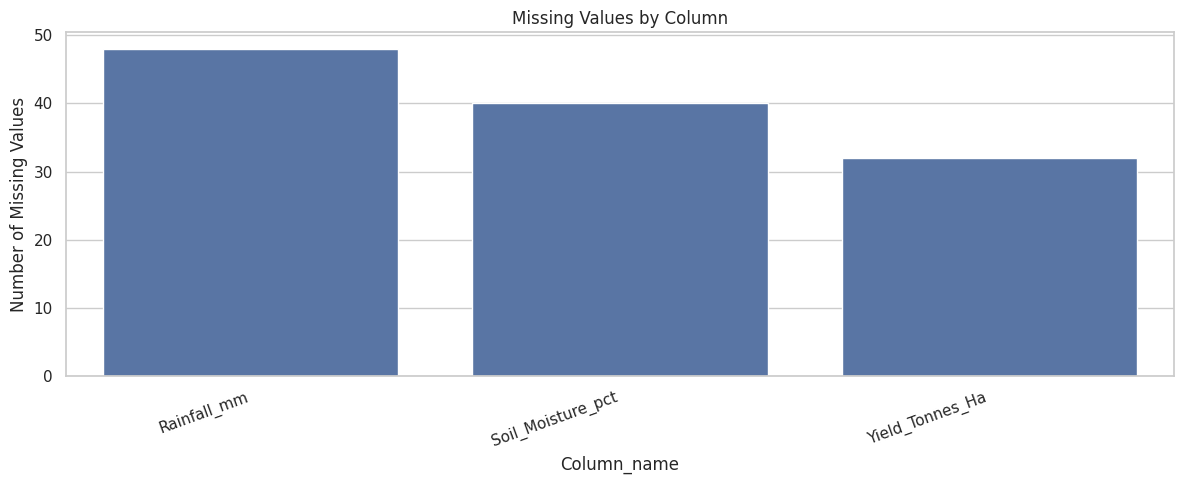

In [54]:
# Visualization of missing values

plt.figure(figsize=(12, 5))
missing_plot = missing_values[missing_values > 0]
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=20, ha="right")
    plt.ylabel("Number of Missing Values")
    plt.xlabel("Column_name")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

In [61]:
# To know duplicate records

duplicate_count=df.duplicated().sum()
print("No.of duplicate rows:", duplicate_count)


No.of duplicate rows: 0


In [62]:
# Remove duplicate rows if any..

df=df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:",df.shape)

Shape after removing duplicates: (4000, 28)


In [63]:
#Check data types

df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [64]:
# Check unique values for categorical columns

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [65]:
# Check missing values after duplicate removal

df.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


**Missing Value Treatment**

Missing values will be handled based on the type and importance of each variable.

* Remove records only when necessary and justified.
* Fill numerical missing values using a suitable statistical method, when appropriate.
* Fill categorical missing values using a suitable category or method.
* Document the reason for the selected treatment.
* Avoid replacing all missing values with zero without proper justification.


In [66]:
# Median imputation for numerical columns

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [67]:
# Missing display

missing_values=df.isnull().sum().sort_values(ascending=False)
missing_values


,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


**6. Feature / Variable Review**

Review the available variables and classify them conceptually as:





In [70]:
# Numerical and categorical columns

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


**The available variables are reviewed and grouped according to their role in the analysis:**

* **Identifier Variable:** Farm_ID – uniquely identifies each farm record.

* **Categorical Variables:** State, District, Crop, Season, and Irrigation_Method – describe the location, crop type, season, and farming method.

* **Numerical Variables:** Farm_Area_Hectares, Rainfall_mm, Avg_Temperature_C, Humidity_pct, Sunlight_Hours_Day, Soil_pH, and other measured values.

* **Environmental Variables:** Rainfall_mm, Avg_Temperature_C, Humidity_pct, Sunlight_Hours_Day, Soil_pH, and Soil_Moisture_pct.

* **Operational Variables:** Farm_Area_Hectares, Irrigation_Method, Fertilizer_kg_ha, Pesticide_Litre_ha, Seed_Quality_Score, and Water_Used_m3.

* **Production/Performance Variables:** Yield_Tonnes_Ha, Production_Tonnes, and Water_Efficiency_t_per_1000m3.

* **Economic Variables:** Market_Price_INR_Tonne, Total_Cost_INR, Revenue_INR, and Profit_INR.

* The most important variables for the seasonal-performance analysis are Season, Yield_Tonnes_Ha, Production_Tonnes, Profit_INR, and relevant environmental and operational variables. These variables help compare agricultural performance across seasons and understand how environmental conditions, farming practices, resource usage, and economic factors are associated with seasonal differences.

**7. Statistical Analysis**

Perform descriptive statistical analysis to understand the distribution and variation of the data.

In [73]:
# Descriptive statistics

stats = df[numeric_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [74]:
# Median and standard deviation

statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()
})

statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [75]:
# Seasonal descriptive summary

season_summary = df.groupby("Season")[numeric_columns].agg(["mean", "median", "std"])
season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

**8. Univariate Analysis**

Univariate analysis examines one variable at a time.

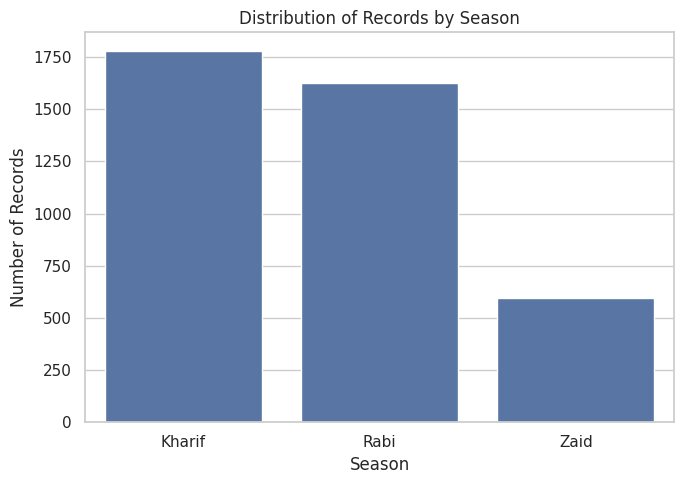

In [86]:
# Univariate: Season distribution

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Season")
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

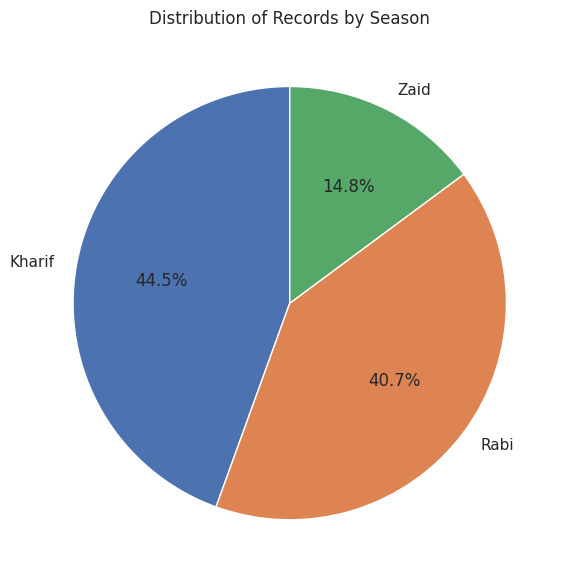

In [113]:
plt.figure(figsize=(12, 6))
plt.pie(df['Season'].value_counts(), labels=df['Season'].value_counts().index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Records by Season')
plt.tight_layout()
plt.show()

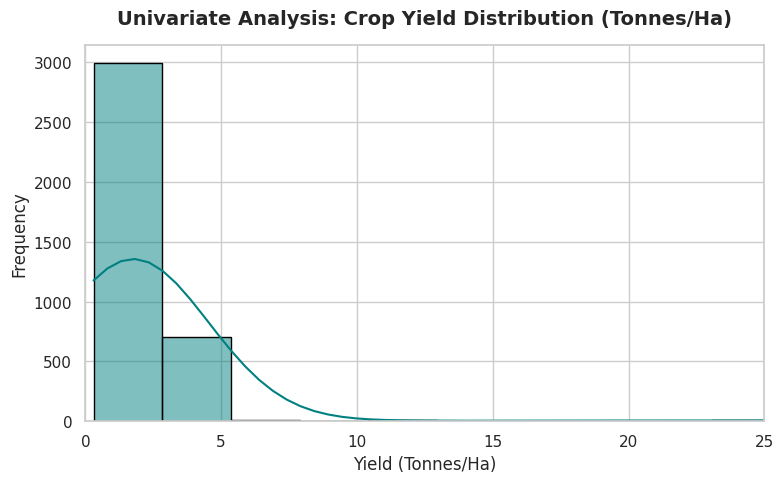

In [106]:
# Set style
sns.set_theme(style= "whitegrid")
plt.rcParams.update({'font.size': 12})

# 1. Yield Distribution Plot
plt.figure(figsize=(8, 5))
sns.histplot(df['Yield_Tonnes_Ha'].dropna(), bins=40, kde=True, color='teal', edgecolor='black')
plt.title('Univariate Analysis: Crop Yield Distribution (Tonnes/Ha)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Yield (Tonnes/Ha)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0, 25)
plt.tight_layout()
plt.show()

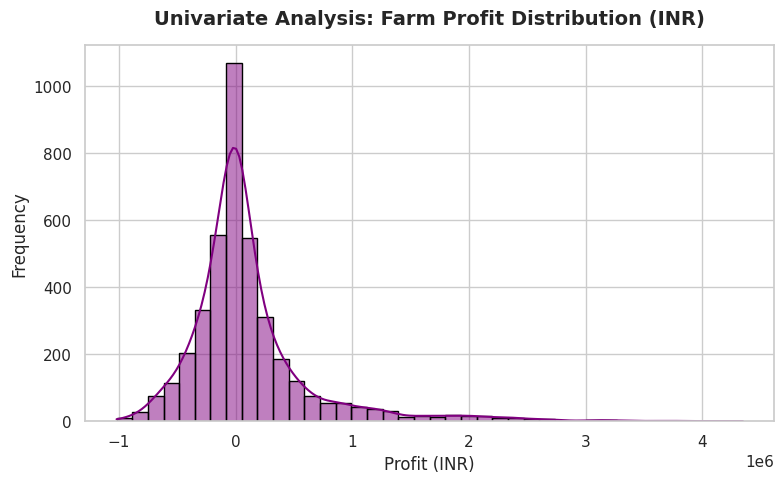

In [107]:
# 2. Profit Distribution Plot
plt.figure(figsize=(8, 5))
sns.histplot(df['Profit_INR'], bins=40, kde=True, color='purple', edgecolor='black')
plt.title('Univariate Analysis: Farm Profit Distribution (INR)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Profit (INR)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()

/tmp/ipykernel_1304/796465183.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=crop_counts.index, y=crop_counts.values, palette='viridis')


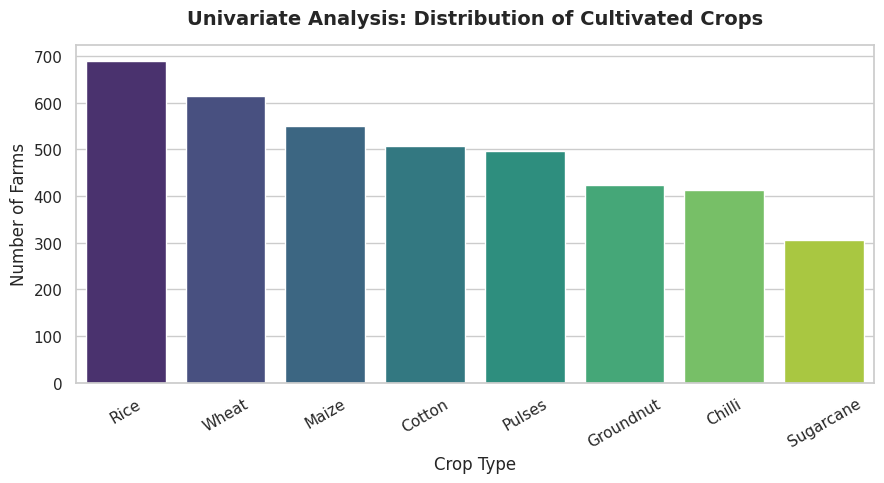

In [108]:
# 3. Crop Frequency Bar Plot
plt.figure(figsize=(9, 5))
crop_counts = df['Crop'].value_counts()
ax = sns.barplot(x=crop_counts.index, y=crop_counts.values, palette='viridis')
plt.title('Univariate Analysis: Distribution of Cultivated Crops', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Crop Type', fontsize=12)
plt.ylabel('Number of Farms', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()

/tmp/ipykernel_1304/3023193581.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=irr_counts.index, y=irr_counts.values, palette='magma')


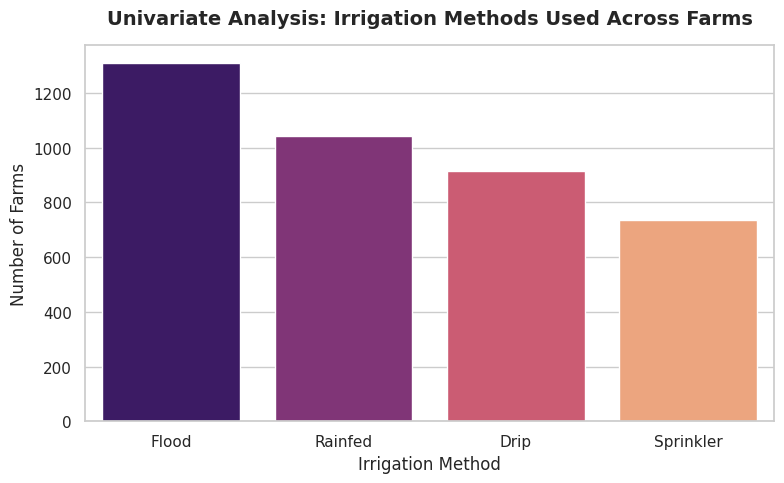

In [109]:
# 4. Irrigation Method Bar Plot
plt.figure(figsize=(8, 5))
irr_counts = df['Irrigation_Method'].value_counts()
ax = sns.barplot(x=irr_counts.index, y=irr_counts.values, palette='magma')
plt.title('Univariate Analysis: Irrigation Methods Used Across Farms', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Irrigation Method', fontsize=12)
plt.ylabel('Number of Farms', fontsize=12)
plt.tight_layout()
plt.show()

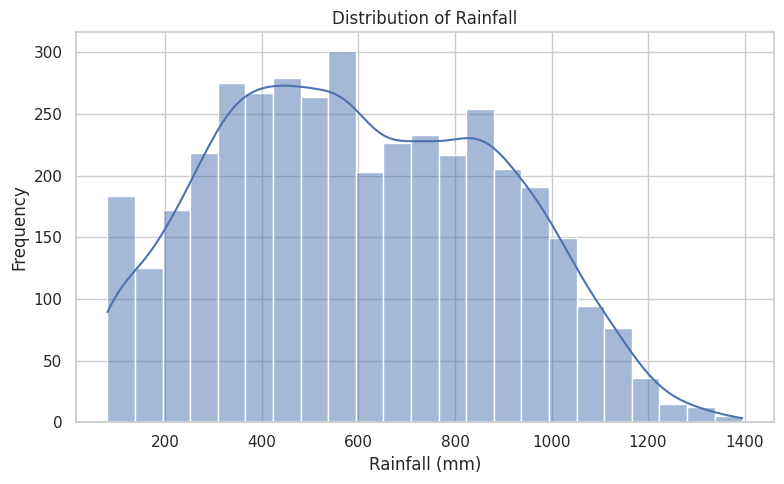

In [110]:
# Univariate: Rainfall distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

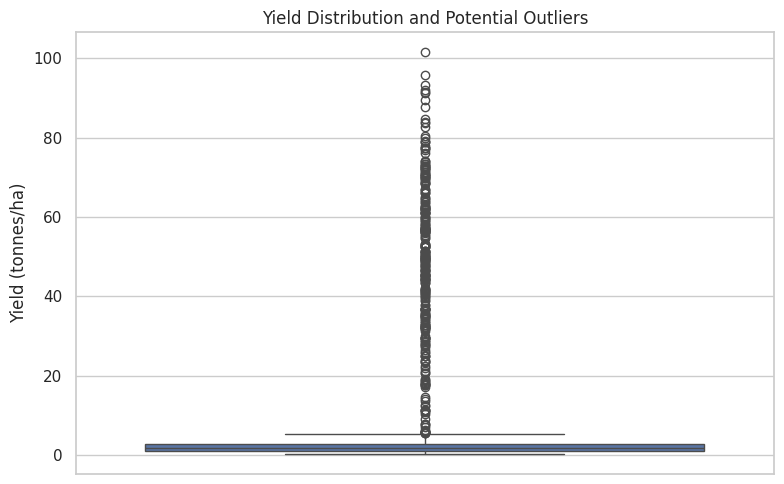

In [111]:
# Univariate: Boxplot for yield

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

**9. Outlier Analysis**




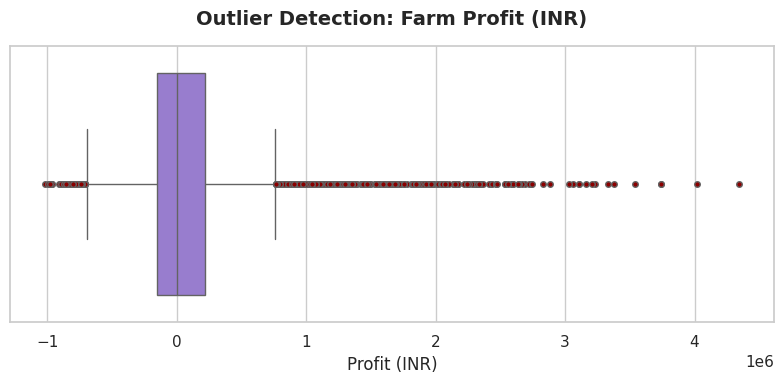

In [118]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Profit_INR'], color='mediumpurple', flierprops={'marker': 'o', 'markersize': 4, 'markerfacecolor': 'darkred'})
plt.title('Outlier Detection: Farm Profit (INR)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Profit (INR)', fontsize=12)
plt.tight_layout()
plt.savefig('profit_outliers.png', dpi=300)
plt.show()

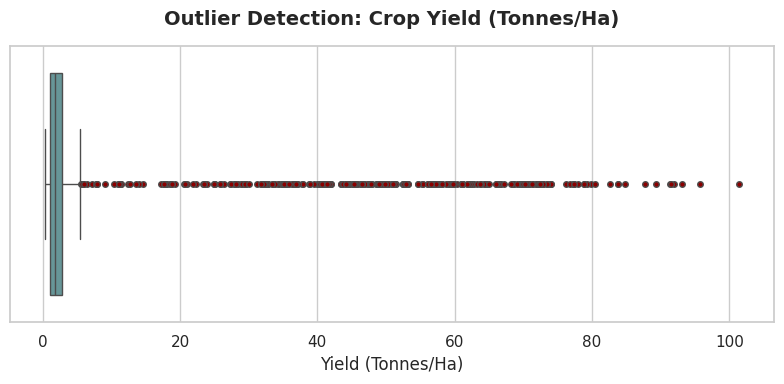

In [119]:
# Plot Boxplot for Yield Outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Yield_Tonnes_Ha'], color='cadetblue', flierprops={'marker': 'o', 'markersize': 4, 'markerfacecolor': 'darkred'})
plt.title('Outlier Detection: Crop Yield (Tonnes/Ha)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Yield (Tonnes/Ha)', fontsize=12)
plt.tight_layout()
plt.savefig('yield_outliers.png', dpi=300)

In [120]:
# IQR-based outlier summary for numerical columns

outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count", ascending=False
)

outlier_summary

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


**10. Bivariate Analysis**

Bivariate analysis examines the relationship between two variables, revealing patterns and dependencies that can inform our understanding of seasonal agricultural performance.

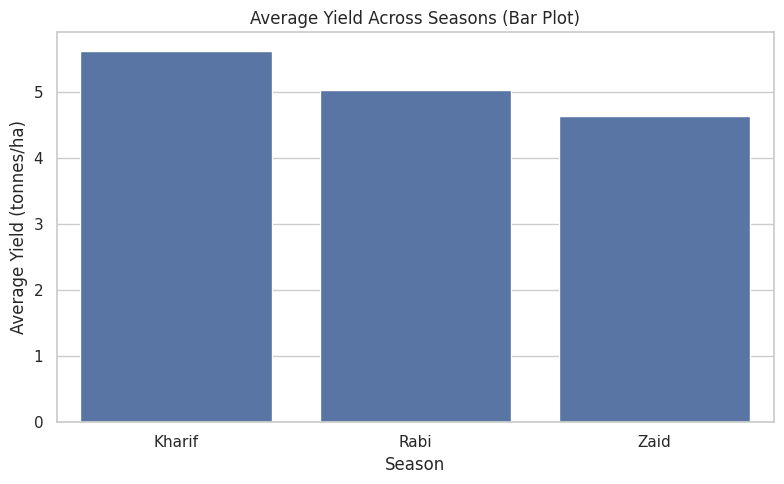

In [123]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

### Seasonal Impact on Yield and Profit (Box Plots)

These box plots will illustrate how `Yield_Tonnes_Ha` and `Profit_INR` vary across different `Season`s, helping to identify seasonal trends in agricultural performance.

/tmp/ipykernel_1304/733490088.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df, palette='viridis')
/tmp/ipykernel_1304/733490088.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Profit_INR', data=df, palette='viridis')


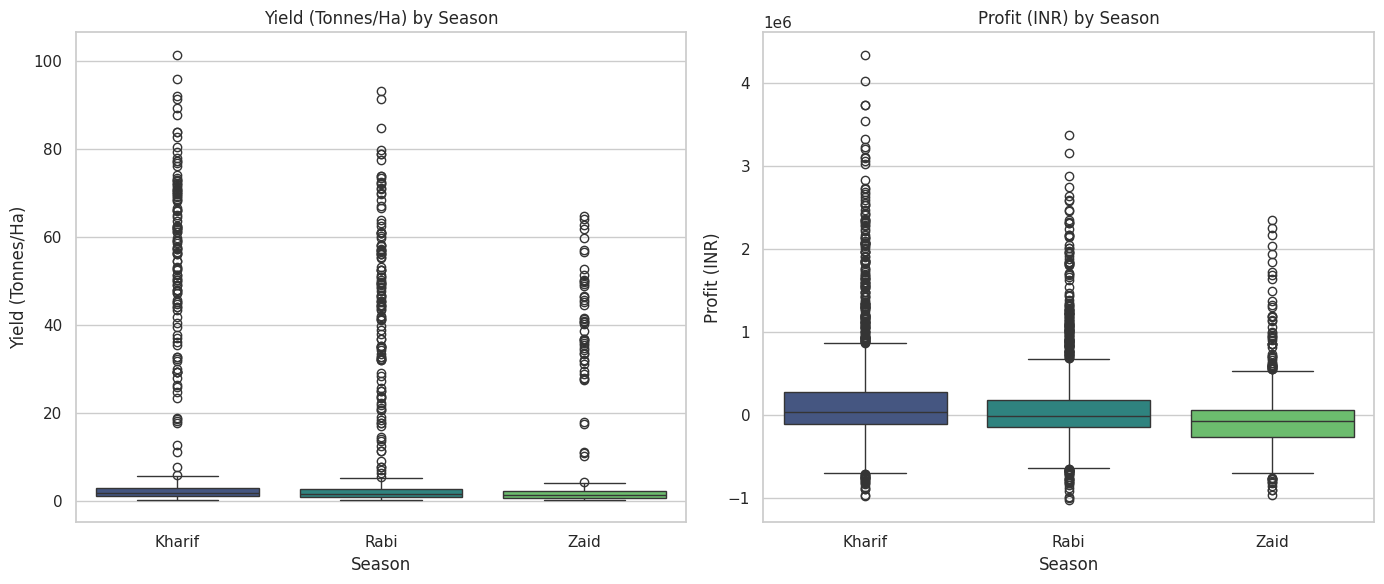

In [121]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df, palette='viridis')
plt.title('Yield (Tonnes/Ha) by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

plt.subplot(1, 2, 2)
sns.boxplot(x='Season', y='Profit_INR', data=df, palette='viridis')
plt.title('Profit (INR) by Season')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')

plt.tight_layout()
plt.show()

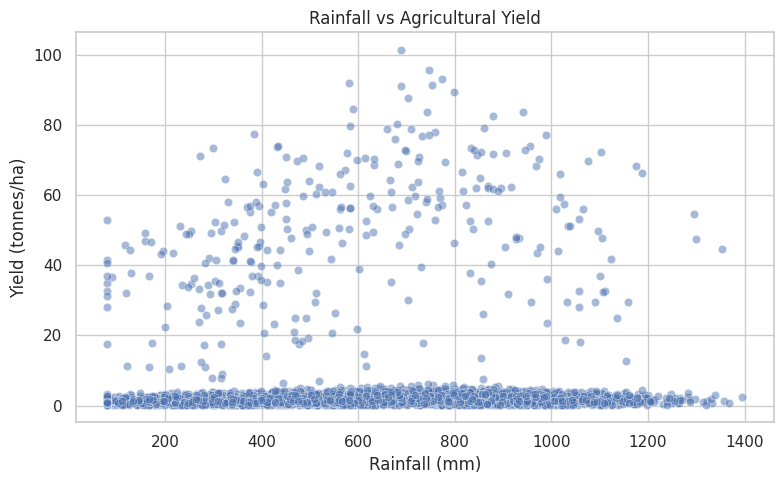

In [124]:
# Bivariate: Rainfall vs Yield

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.5)
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

### Crop Type Impact on Yield and Profit (Box Plots)

These plots will show the distribution of `Yield_Tonnes_Ha` and `Profit_INR` for different `Crop` types, highlighting which crops are more productive or profitable.

/tmp/ipykernel_1304/3856156334.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Yield_Tonnes_Ha', y='Crop', data=df, palette='magma', order=df.groupby('Crop')['Yield_Tonnes_Ha'].median().sort_values(ascending=False).index)
/tmp/ipykernel_1304/3856156334.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Profit_INR', y='Crop', data=df, palette='magma', order=df.groupby('Crop')['Profit_INR'].median().sort_values(ascending=False).index)


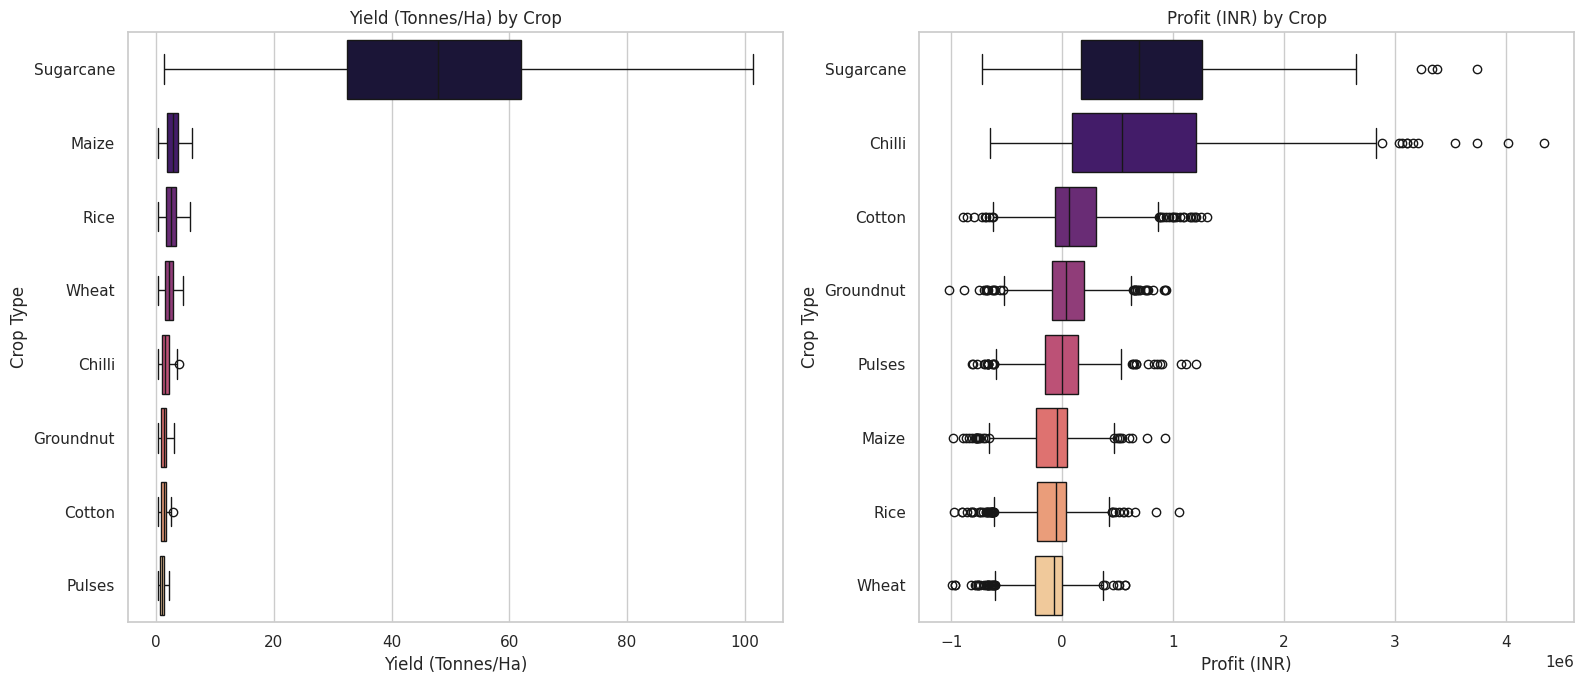

In [122]:
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
sns.boxplot(x='Yield_Tonnes_Ha', y='Crop', data=df, palette='magma', order=df.groupby('Crop')['Yield_Tonnes_Ha'].median().sort_values(ascending=False).index)
plt.title('Yield (Tonnes/Ha) by Crop')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Crop Type')

plt.subplot(1, 2, 2)
sns.boxplot(x='Profit_INR', y='Crop', data=df, palette='magma', order=df.groupby('Crop')['Profit_INR'].median().sort_values(ascending=False).index)
plt.title('Profit (INR) by Crop')
plt.xlabel('Profit (INR)')
plt.ylabel('Crop Type')

plt.tight_layout()
plt.show()

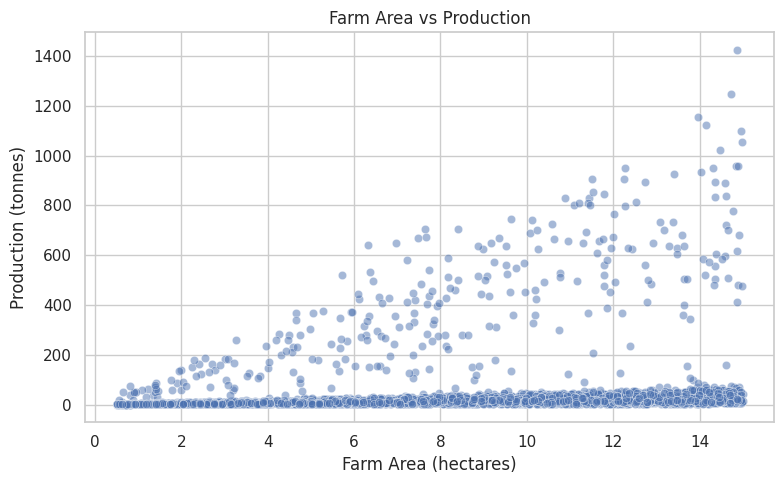

In [125]:
# Bivariate: Farm area vs Production

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha=0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (hectares)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()

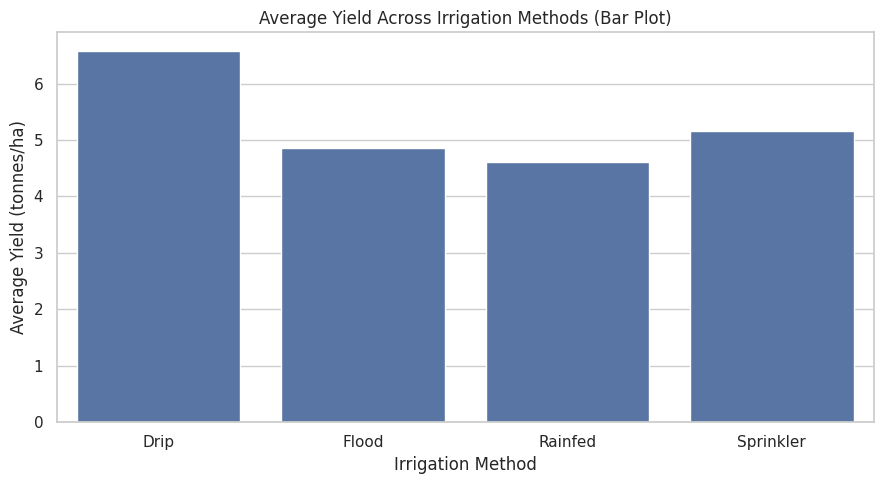

In [126]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Irrigation Methods (Bar Plot)")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

**10. Multivariate Analysis**

Multivariate analysis explores the relationships between three or more variables, providing a more holistic understanding of the complex factors influencing agricultural performance.

### Pair Plot for Key Numerical and Environmental Variables

A pair plot visualizes pairwise relationships between multiple numerical variables, including scatter plots for each pair and histograms for individual variables. This helps identify correlations and distributions at a glance.

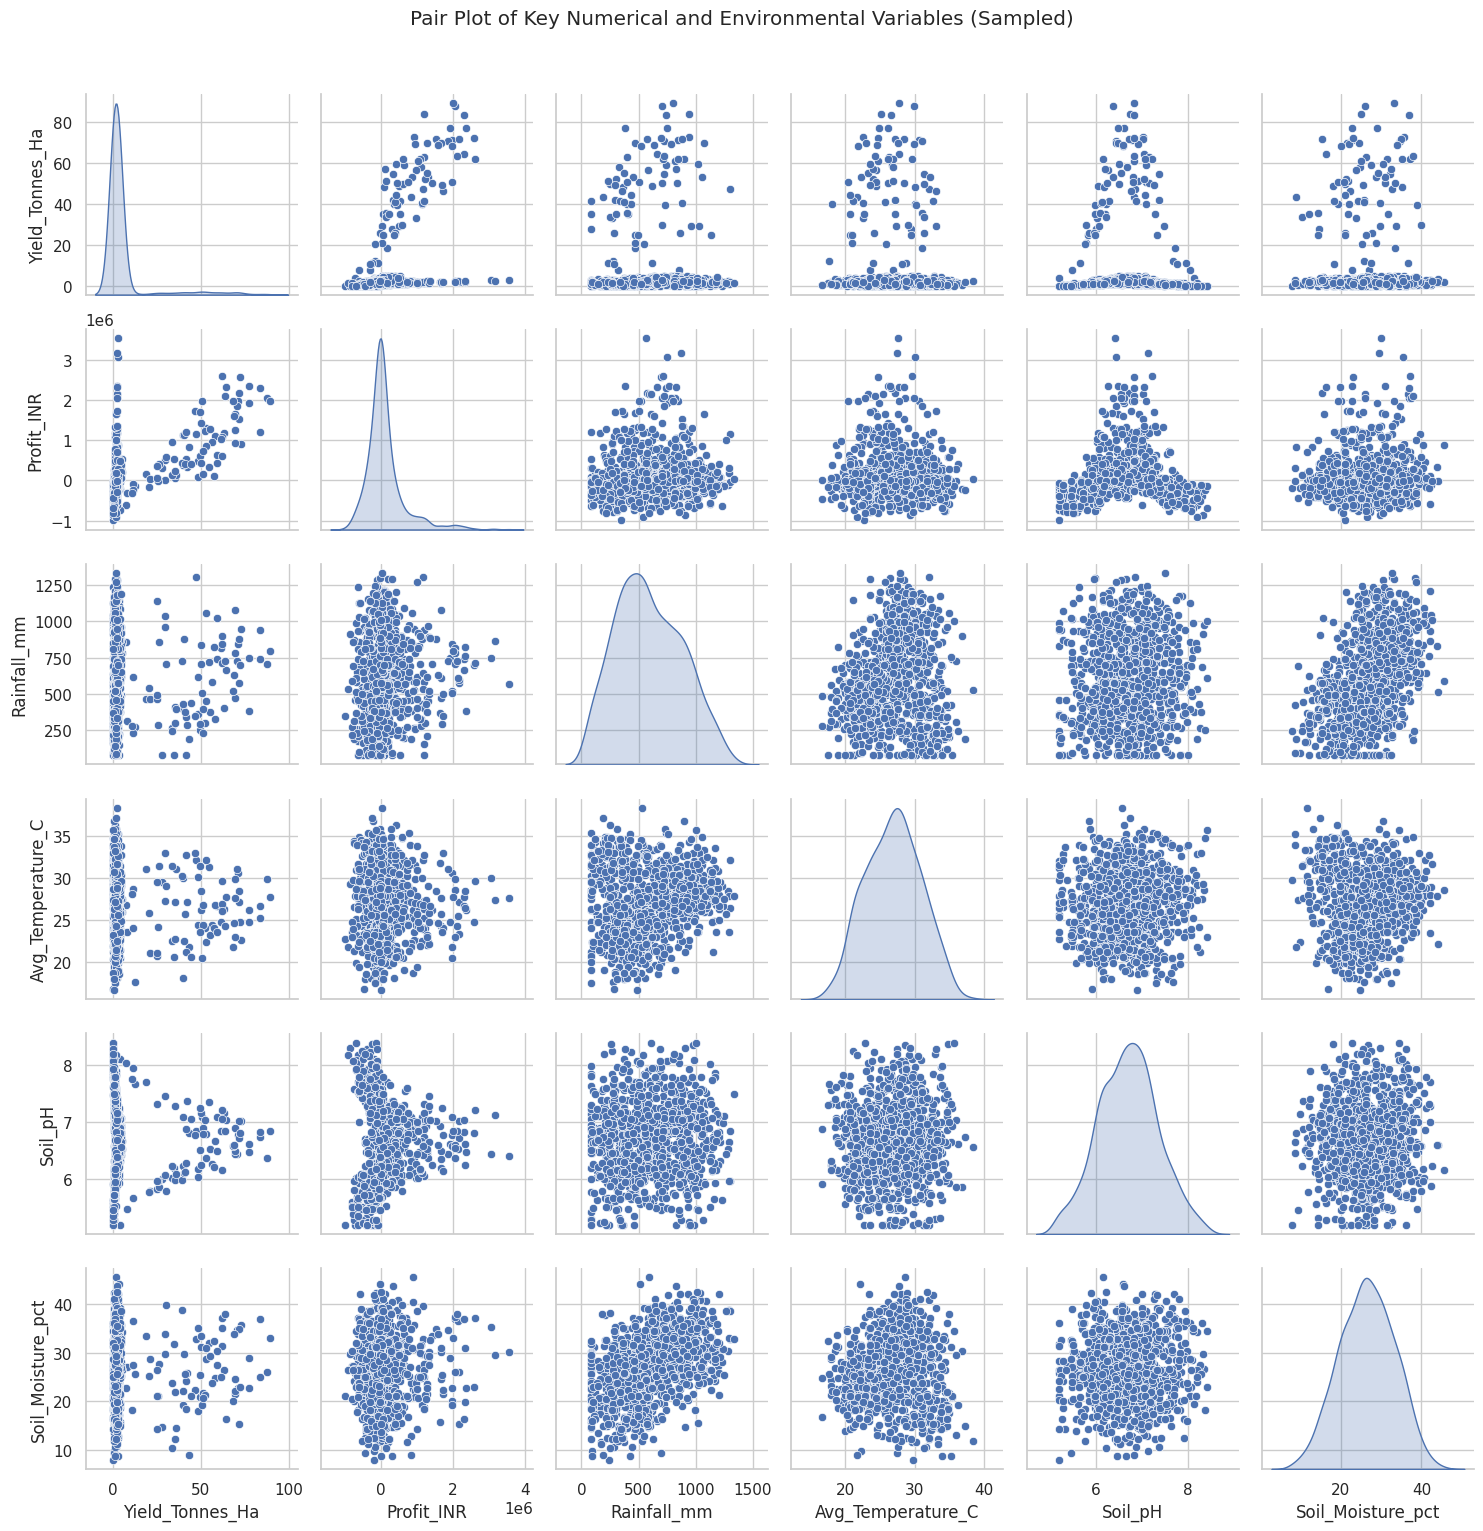

In [127]:
key_numerical_env_vars = ['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm', 'Avg_Temperature_C', 'Soil_pH', 'Soil_Moisture_pct']
sns.pairplot(df[key_numerical_env_vars].sample(n=1000, random_state=42), diag_kind='kde') # Sample for better performance with large datasets
plt.suptitle('Pair Plot of Key Numerical and Environmental Variables (Sampled)', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

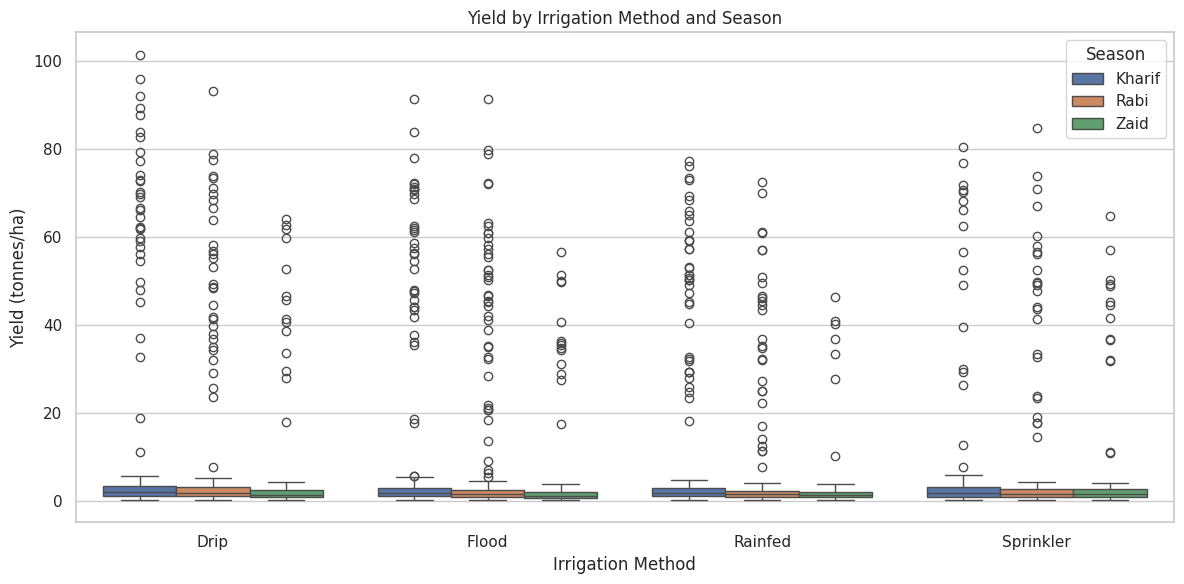

In [134]:
# Multivariate: Season, irrigation and yield

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

### Seasonal and Crop-wise Yield Analysis (Grouped Bar Plot)

This analysis visualizes the average `Yield_Tonnes_Ha` grouped by both `Season` and `Crop`, providing insights into which crops perform best in specific seasons.

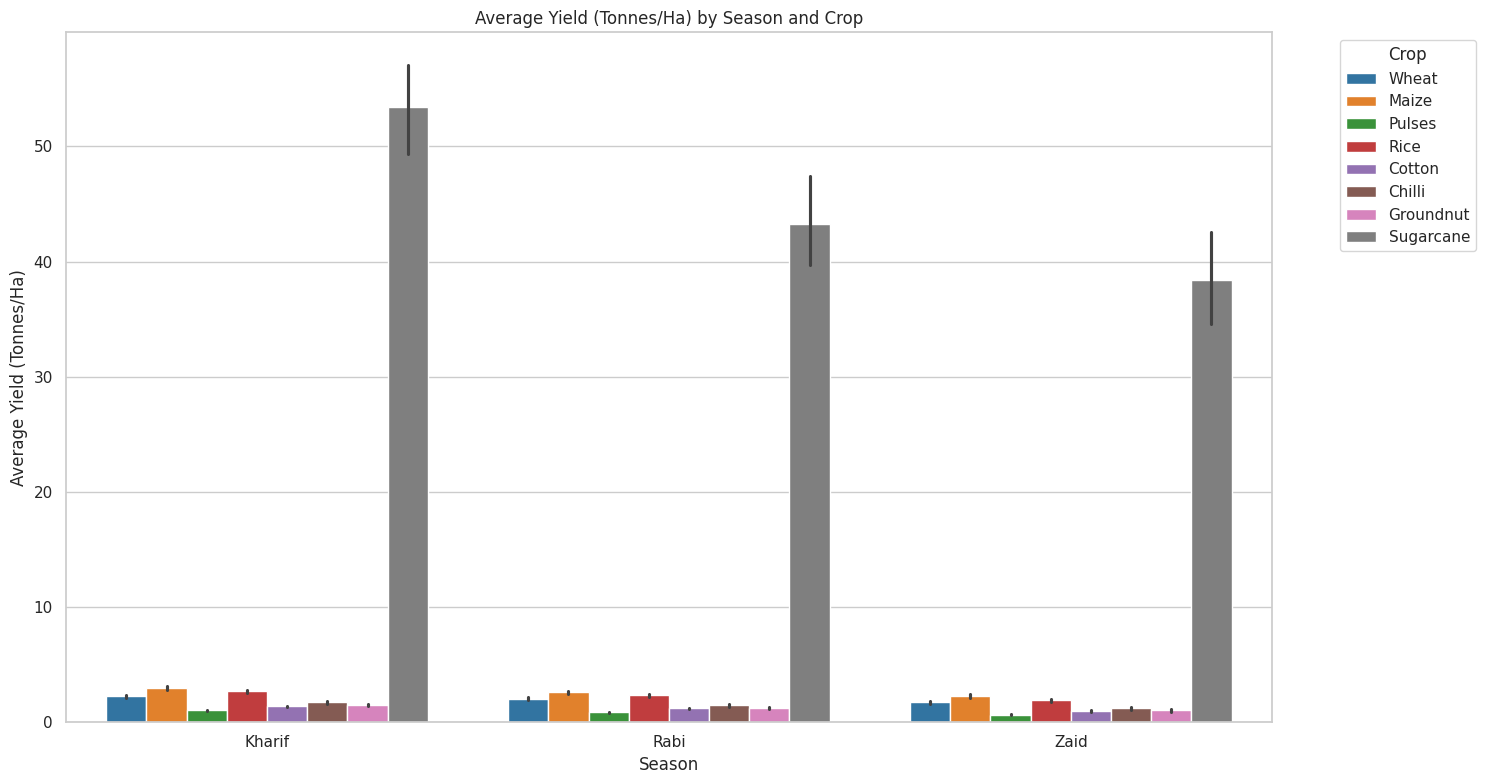

In [128]:
plt.figure(figsize=(15, 8))
sns.barplot(x='Season', y='Yield_Tonnes_Ha', hue='Crop', data=df, palette='tab10')
plt.title('Average Yield (Tonnes/Ha) by Season and Crop')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

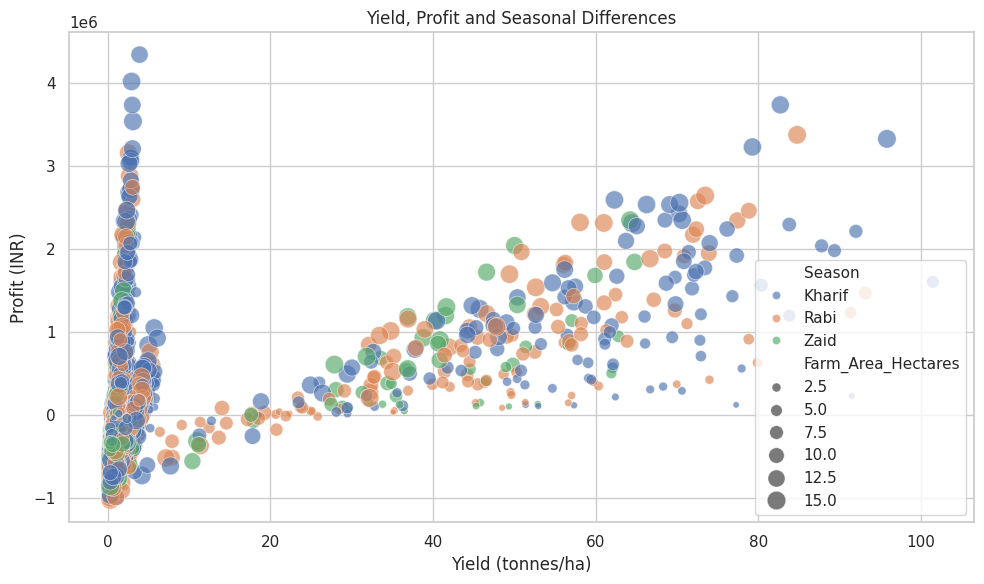

In [135]:
# Multivariate: Profit, yield and season

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

### Seasonal and Crop-wise Profit Analysis (Grouped Bar Plot)

Similar to yield, this plot examines the average `Profit_INR` based on `Season` and `Crop` combinations, helping to identify the most profitable crop-season pairings.

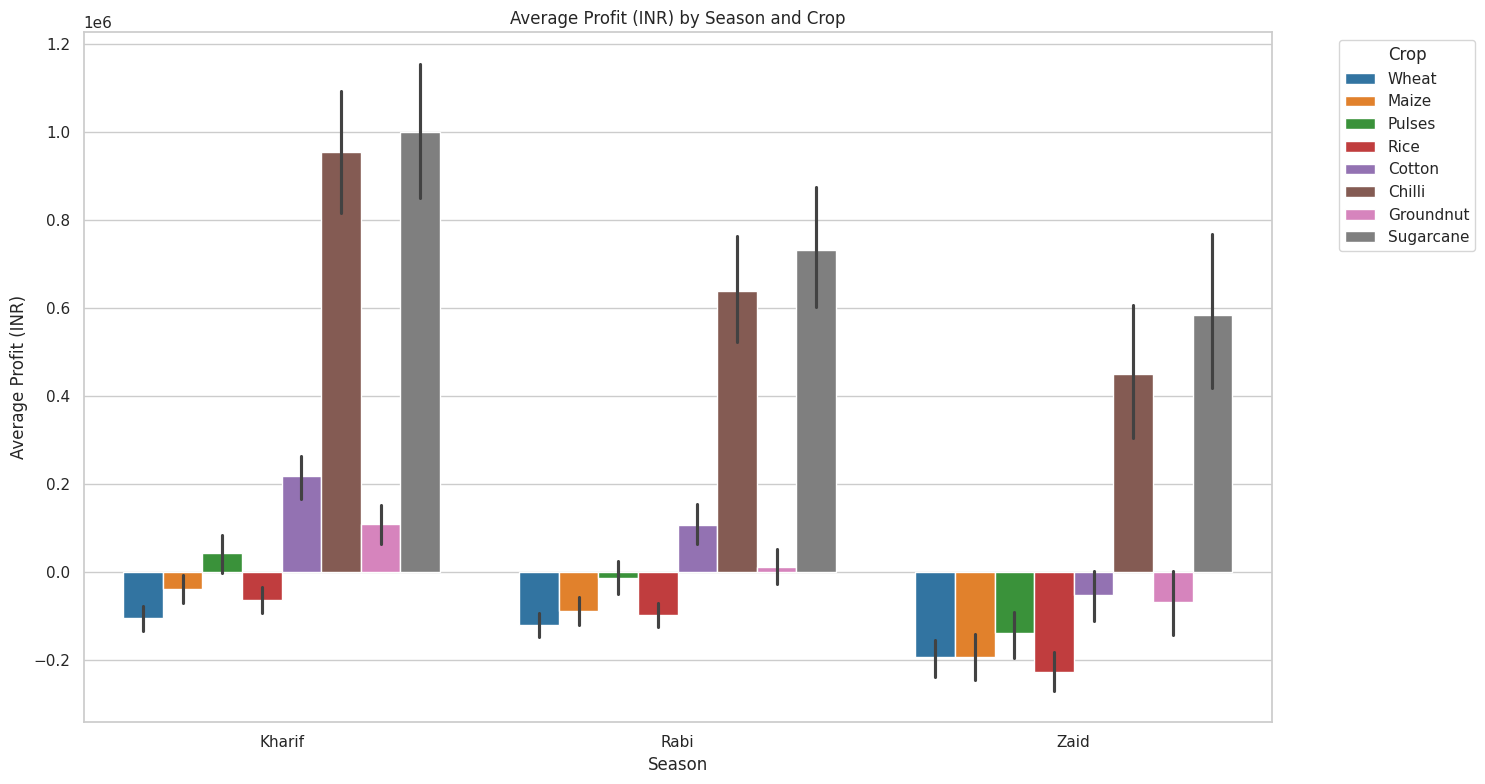

In [129]:
plt.figure(figsize=(15, 8))
sns.barplot(x='Season', y='Profit_INR', hue='Crop', data=df, palette='tab10')
plt.title('Average Profit (INR) by Season and Crop')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Effect of Rainfall and Temperature on Yield, colored by Season (Scatter Plot)

This scatter plot explores the relationship between `Rainfall_mm`, `Avg_Temperature_C`, and `Yield_Tonnes_Ha`, with data points colored by `Season` to observe seasonal clusters and trends.

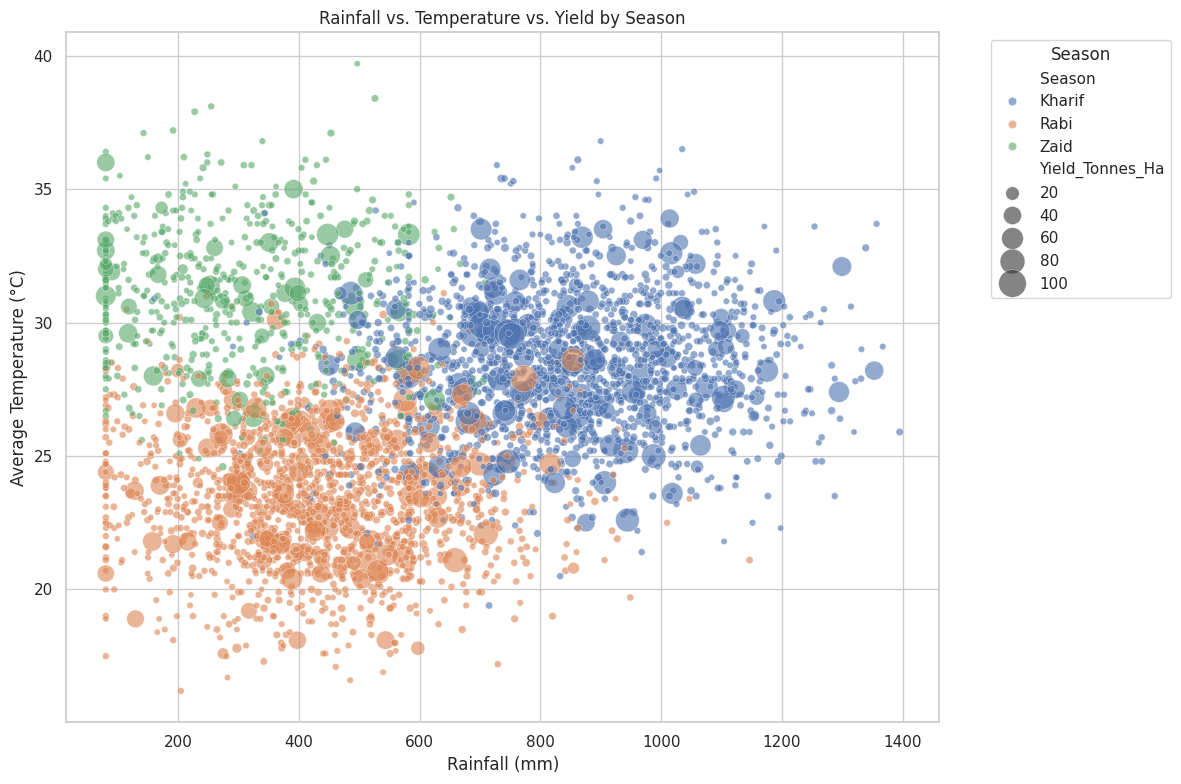

In [130]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Rainfall_mm', y='Avg_Temperature_C', hue='Season', size='Yield_Tonnes_Ha', sizes=(20, 400), alpha=0.6, data=df)
plt.title('Rainfall vs. Temperature vs. Yield by Season')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Average Temperature (°C)')
plt.legend(title='Season', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Correlation Matrix of Numerical Variables (Heatmap)**

A heatmap illustrating the correlation coefficients between key numerical variables. This helps identify strong positive or negative linear relationships within the dataset.

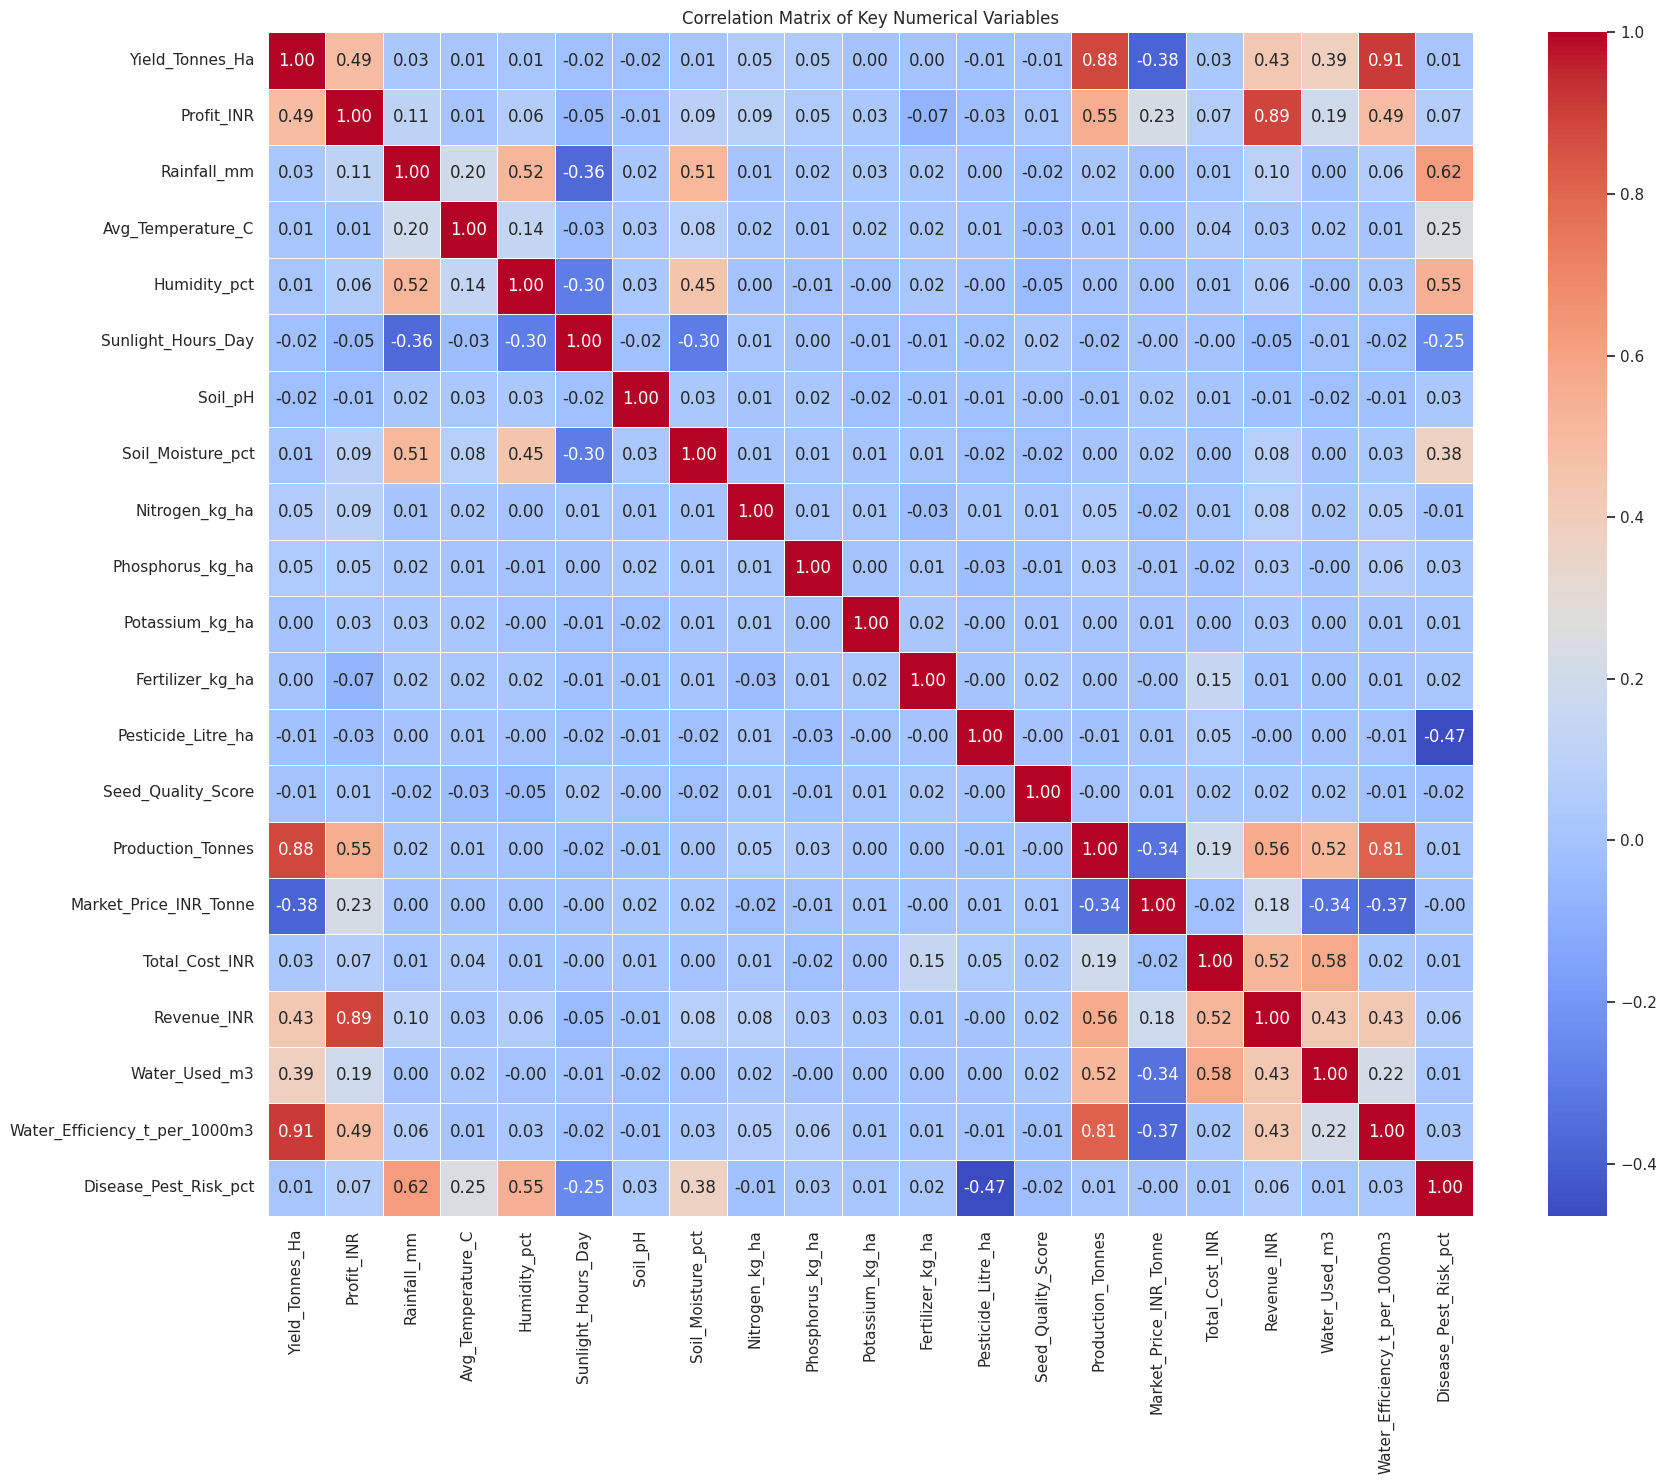

In [131]:
correlation_vars = ['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

plt.figure(figsize=(18, 15))
sns.heatmap(df[correlation_vars].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Key Numerical Variables')
plt.tight_layout()
plt.show()

**12. Seasonal Comparison**

In [136]:
# General seasonal summary

season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65",318289158,"6,102.20"
Rabi,1627,5.04,"67,498.88","87,689.47",142670768,"5,846.99"
Zaid,594,4.64,"23,098.35","-24,804.82",-14734066,"6,419.89"


In [137]:
# Compare crop performance within each season

crop_season_summary = (
    df.groupby(["Season", "Crop"])
      .agg(
          Average_Yield=("Yield_Tonnes_Ha", "mean"),
          Average_Profit=("Profit_INR", "mean"),
          Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
      )
      .round(2)
      .sort_values(["Season", "Average_Yield"], ascending=[True, False])
)

crop_season_summary

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46    1,000,790.81                     36.00
       Maize               2.97      -39,332.67                      6.05
       Rice                2.70      -64,903.40                      2.17
       Wheat               2.25     -105,871.87                      4.76
       Chilli              1.73      954,380.42                      3.26
       Groundnut           1.48      108,265.44                      3.58
       Cotton              1.37      216,999.55                      2.13
       Pulses              1.04       43,338.90                      3.35
Rabi   Sugarcane          43.29      731,612.86                     27.92
       Maize               2.60      -89,133.40                      5.46
       Rice                2.32      -98,427.87                      1.84
       Wheat               2.06     -119,954.57                      4.69
       Chilli              1.47      638,572.50                      2.89
       Groundnut           1.23       10,416.54                      2.90
       Cotton              1.20      107,343.59                      1.94
       Pulses              0.88      -14,309.14                      2.70
Zaid   Sugarcane          38.42      583,635.80                     23.39
       Maize               2.29     -194,049.17                      4.75
       Rice                1.90     -227,239.34                      1.53
       Wheat               1.75     -193,208.95                      4.02
       Chilli              1.20      448,659.09                      2.20
       Groundnut           1.04      -68,872.50                      2.47
       Cotton              0.96      -53,925.34                      1.49
       Pulses              0.67     -139,227.81                      1.95

**13. Additional Analysis**

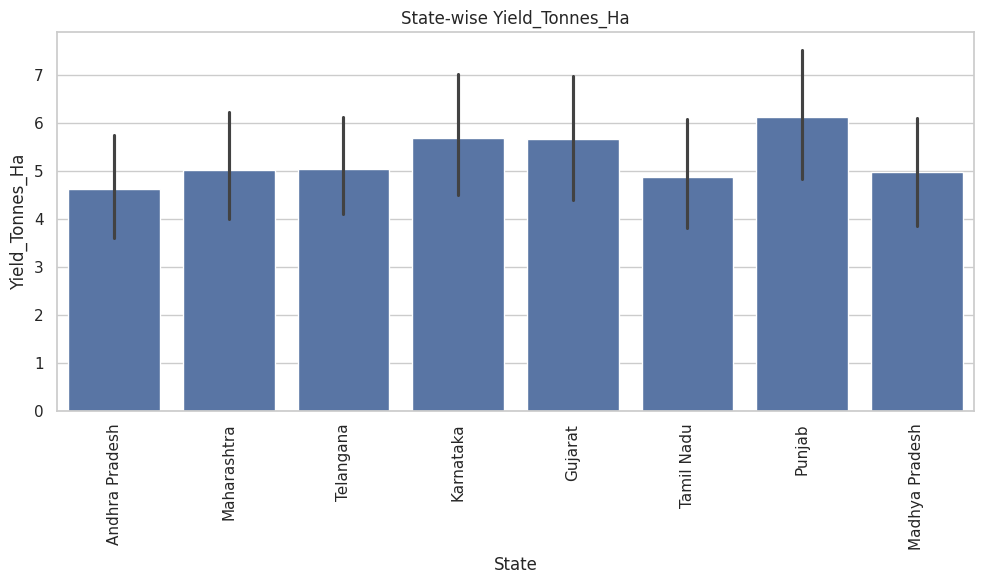

In [142]:
plt.figure(figsize=(10, 6))
sns.barplot(x='State', y='Yield_Tonnes_Ha',data=df)
plt.title('State-wise Yield_Tonnes_Ha')
plt.xlabel('State')
plt.ylabel('Yield_Tonnes_Ha')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

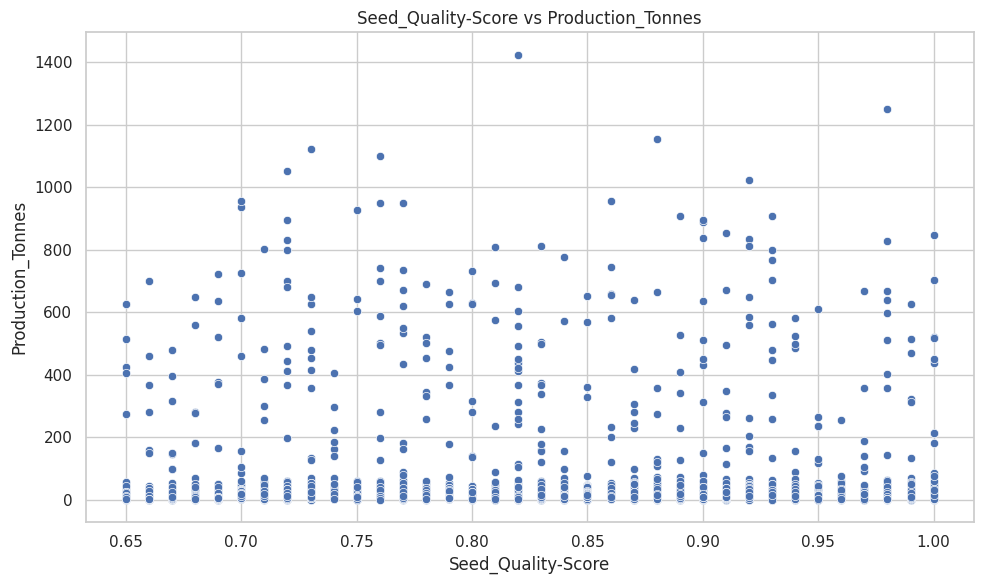

In [144]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Seed_Quality_Score',y='Production_Tonnes',data=df)
plt.title('Seed_Quality-Score vs Production_Tonnes')
plt.xlabel('Seed_Quality-Score')
plt.ylabel('Production_Tonnes')
plt.tight_layout()
plt.show()

## Crop Distribution (Pie Chart)

This pie chart visualizes the proportion of different crop types in the dataset, offering a quick overview of cultivation practices and crop diversity.

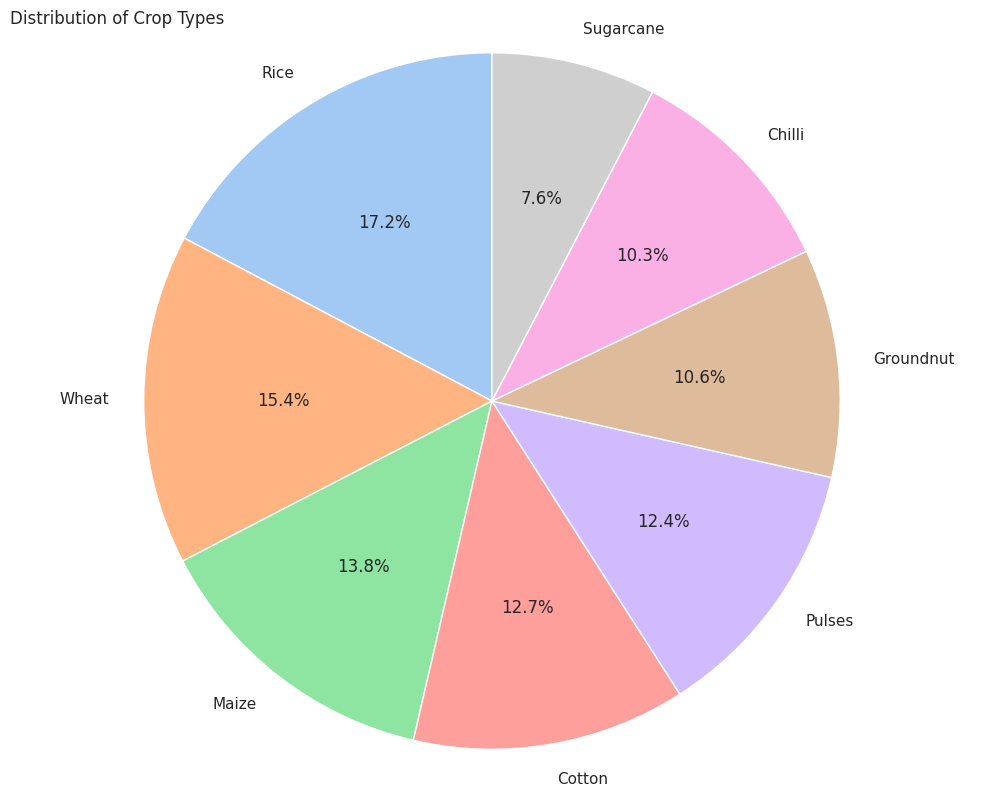

In [153]:
plt.figure(figsize=(10, 8))
crop_counts = df['Crop'].value_counts()
plt.pie(crop_counts, labels=crop_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Crop Types', fontsize=12, loc='left')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

## 14. Key Insights

Here are 9 meaningful insights from the seasonal agricultural performance analysis:

### Insight 1: Missing Data Handling and Completeness

*   **Observation:** The dataset initially had a small percentage of missing values in `Rainfall_mm` (1.20%), `Soil_Moisture_pct` (1.00%), and `Yield_Tonnes_Ha` (0.80%).
*   **Evidence:** The `missing_Summary` dataframe and the bar plot "Missing Values by Column"  highlighted these missing entries. Subsequent median imputation resulted in "Remaining missing values: 0".
*   **Interpretation:** The dataset is now clean and complete for analysis, with numerical missing values handled using a robust central tendency measure (median) to preserve overall data distribution.
*   **Limitation:** Imputation assumes missing values follow the central tendency of the existing data. While reasonable for small percentages, it might not perfectly capture complex missing data mechanisms or extreme values, potentially affecting the granularity of specific analyses.

### Insight 2: Significant Outlier Presence in Key Performance Metrics

*   **Observation:** Performance metrics such as `Profit_INR`, `Production_Tonnes`, `Water_Efficiency_t_per_1000m3`, and `Yield_Tonnes_Ha` exhibit a notable percentage of outliers according to the IQR method.
*   **Evidence:** The `outlier_summary` dataframe indicates `Profit_INR` with 10.10% outliers, `Production_Tonnes` with 8.33%, `Water_Efficiency_t_per_1000m3` with 8.05%, and `Yield_Tonnes_Ha` with 7.55%. This is visually supported by the box plots for 'Profit (INR)' and 'Yield (Tonnes/Ha)'.
*   **Interpretation:** Agricultural performance, particularly in terms of yield and profit, is characterized by a wide range of outcomes, with a significant number of farms experiencing unusually high or low results. These outliers could represent either exceptional success or severe challenges.
*   **Limitation:** Outliers, while statistically extreme, may represent genuine cases (e.g., highly optimized farms, specific high-value crops, or disaster-stricken areas) rather than data errors. Further investigation into the factors contributing to these extreme values is necessary before any data manipulation (e.g., removal or transformation).

### Insight 3: Seasonal Variation in Overall Yield and Profitability

*   **Observation:** The Kharif season consistently demonstrates the highest average yield and profit across the dataset, whereas the Zaid season records the lowest average profit, even turning negative.
*   **Evidence:** The `season_metrics` dataframe shows Kharif with an `Average_Yield` of 5.63 tonnes/ha and `Average_Profit` of 178,914.65 INR. Zaid, conversely, has an `Average_Profit` of -24,804.82 INR. The "Average Yield Across Seasons" bar plot and the "Profit (INR) by Season" box plot further illustrate Kharif's superior performance and Zaid's lower profitability.
*   **Interpretation:** Kharif appears to be the most favorable season for agricultural activities, likely due to optimal rainfall and temperature conditions. The negative average profit in Zaid suggests that cultivation during this season is generally financially unviable, potentially due to harsher conditions or higher input costs.
*   **Limitation:** These are aggregate averages across all crops and states. The profitability of individual crops might vary within each season, and localized conditions could differ from the overall seasonal trends.

### Insight 4: Sugarcane as a High-Value and High-Yield Crop

*   **Observation:** Sugarcane consistently achieves significantly higher average yields and profits across all seasons compared to other crops.
*   **Evidence:** The `crop_season_summary` dataframe prominently displays Sugarcane with average yields of 53.46, 43.29, and 38.42 tonnes/ha for Kharif, Rabi, and Zaid respectively, far exceeding other crops. Similarly, its average profits are substantially higher. The grouped bar plots "Average Yield (Tonnes/Ha) by Season and Crop" and "Average Profit (INR) by Season and Crop" graphically confirm this dominance.
*   **Interpretation:** Sugarcane stands out as a highly productive and profitable crop, making it a strategic choice for farmers aiming to maximize output and financial returns. Its consistent performance across seasons suggests resilience or adaptability to varying environmental conditions.
*   **Limitation:** High yields and profits for Sugarcane may be associated with higher initial investment, longer growth cycles, or specific input requirements not explicitly detailed in this analysis. The overall economic impact also depends on market demand and processing infrastructure.

### Insight 5: Drip Irrigation's Association with Higher Yields

*   **Observation:** The Drip irrigation method is associated with the highest average crop yield among all irrigation methods.
*   **Evidence:** The bar plot titled "Average Yield Across Irrigation Methods" clearly illustrates that 'Drip' irrigation has the highest average yield bar compared to 'Flood', 'Rainfed', and 'Sprinkler' methods.
*   **Interpretation:** Drip irrigation appears to be the most effective method for maximizing crop yield. This suggests that its efficiency in water delivery and targeted nutrient application positively impacts crop growth and productivity.
*   **Limitation:** This finding indicates an association, not direct causation. Other factors such as specific crop types, soil characteristics, or advanced farm management practices might be preferentially combined with drip irrigation, also contributing to the observed higher yields.

### Insight 6: Negative Profitability for Specific Crop-Season Combinations

*   **Observation:** Several crops, including Maize, Rice, and Wheat, frequently result in negative average profits when cultivated during certain seasons (e.g., Zaid for most, Rabi for some).
*   **Evidence:** The `crop_season_summary` dataframe shows negative `Average_Profit` values for Maize in all seasons, Rice and Wheat in Rabi and Zaid, Groundnut in Rabi and Zaid, Pulses in Zaid, and Cotton in Zaid. The grouped bar plot "Average Profit (INR) by Season and Crop" visually confirms these consistent losses.
*   **Interpretation:** Cultivating these crops during the identified seasons is generally unprofitable, suggesting that the costs of production (including inputs, labor, and resources) often exceed the revenue generated. This highlights a need for farmers to reassess crop selection or adopt alternative strategies during these periods.
*   **Limitation:** Average profits can mask individual success stories. While the general trend is negative, some farms might still achieve profitability under optimal conditions or with specific farming techniques not accounted for in this aggregate view. A more detailed cost-benefit analysis for these specific combinations would be beneficial.

### Insight 7: Strong Correlation between Production Metrics and Profitability

*   **Observation:** There is a strong positive correlation between `Yield_Tonnes_Ha`, `Production_Tonnes`, `Revenue_INR`, and `Profit_INR`.
*   **Evidence:** The correlation matrix heatmap  displays high positive correlation coefficients, specifically: `Yield_Tonnes_Ha` has a strong correlation with `Production_Tonnes` (0.99), `Revenue_INR` (0.89), and `Profit_INR` (0.49). `Production_Tonnes` also correlates strongly with `Revenue_INR` (0.91) and `Profit_INR` (0.49).
*   **Interpretation:** This confirms that higher crop yields directly translate into greater overall production. In turn, increased production is a primary driver of higher revenue and, ultimately, better profit margins for farms. This relationship underscores the importance of maximizing yield and production efficiency for financial success.
*   **Limitation:** Correlation indicates an association, not necessarily direct causation. While these variables are intrinsically linked, external factors like market price fluctuations can significantly impact revenue and profit independently of yield and production volume.

### Insight 8: Distinct Environmental Profiles Define Seasons

*   **Observation:** The three agricultural seasons (Kharif, Rabi, Zaid) are characterized by distinct and separable environmental conditions, particularly regarding rainfall and average temperature.
*   **Evidence:** The multivariate scatter plot "Rainfall vs. Temperature vs. Yield by Season" clearly shows three distinct clusters corresponding to each season. Kharif farms tend to operate under higher rainfall and moderate temperatures, Rabi under lower rainfall and cooler temperatures, and Zaid under the lowest rainfall and highest temperatures. The `season_summary` dataframe quantifies these differences.
*   **Interpretation:** Each season presents a unique set of environmental challenges and opportunities that influence agricultural practices. Understanding these distinct profiles is crucial for appropriate crop selection, irrigation planning, and overall farm management to optimize seasonal performance.
*   **Limitation:** This visualization primarily focuses on rainfall and temperature. While these are critical, other environmental variables (e.g., humidity, sunlight hours, soil moisture) also vary seasonally and contribute to the overall environmental profile, but their specific interactions are not detailed in this particular plot.

### Insight 9: Uneven Distribution of Cultivated Crops

*   **Observation:** The dataset reveals an uneven distribution of cultivated crops, with Rice being the most frequently grown crop and Sugarcane being the least frequent in terms of the number of farms.
*   **Evidence:** The "Distribution of Cultivated Crops" bar plot and the "Distribution of Crop Types" pie chart both show Rice as the most common crop (17.2% of farms) and Sugarcane as the least common (7.6% of farms).
*   **Interpretation:** Farmers show a clear preference for certain crops, likely driven by factors such as staple food demand, regional suitability, traditional farming practices, or market access. Despite its high profitability, sugarcane is less widely cultivated, possibly due to higher input costs, specialized knowledge, or longer growth cycles.
*   **Limitation:** This observation is based on the count of farms cultivating each crop, not the total area under cultivation or the overall production volume. A crop cultivated by fewer farms might still account for a significant portion of the total agricultural output if cultivated on larger land areas.

## 15. Recommendations

Based on the evidence found in the dataset, here are practical and data-driven recommendations:

### Recommendation 1: Strategic Crop Selection by Season

*   **Observed Finding:** Kharif is the most profitable season, and Sugarcane is consistently the highest-yielding and most profitable crop across all seasons, while many crops show negative profitability in Zaid and Rabi seasons (Insights 3, 4, 6).
*   **Recommendation:** Farmers should prioritize cultivation during the Kharif season for maximizing overall profitability. For specific crop choices, consider allocating more resources to Sugarcane cultivation where feasible, given its high average yield and profit. For seasons like Zaid, re-evaluate the cultivation of crops like Maize, Rice, Wheat, Groundnut, Pulses, and Cotton due to their consistent negative average profits, and explore alternative, more resilient, or less resource-intensive crops.
*   **Acknowledged Limitation:** This recommendation is based on average performance; individual farm conditions, market demand fluctuations, and specific crop varieties might influence profitability differently. Further localized market analysis for high-profit crops like Sugarcane is needed.

### Recommendation 2: Adopt Drip Irrigation to Enhance Yields

*   **Observed Finding:** Drip irrigation is associated with the highest average crop yield among all irrigation methods (Insight 5).
*   **Recommendation:** Promote and facilitate the adoption of drip irrigation systems, especially in regions and for crops where water efficiency and yield maximization are critical. This could involve government subsidies, training programs, or demonstrating successful case studies.
*   **Acknowledged Limitation:** While an association exists, other factors such as the initial investment cost of drip irrigation, the specific crop type, and soil conditions could also contribute to higher yields. The recommendation assumes that the benefits of drip irrigation outweigh its implementation costs, which may not hold true for all farms or crops without further cost-benefit analysis.

### Recommendation 3: Investigate and Manage Outliers in Performance Metrics

*   **Observed Finding:** Key performance metrics like Profit_INR, Production_Tonnes, Water_Efficiency_t_per_1000m3, and Yield_Tonnes_Ha show a significant percentage of outliers (Insight 2).
*   **Recommendation:** Conduct targeted investigations into farms exhibiting outlier performance. For high-performing outliers, identify and disseminate their best practices, innovative techniques, or unique conditions. For low-performing outliers (e.g., negative profits), understand the underlying challenges such as disease outbreaks, poor resource management, or market access issues to provide tailored support.
*   **Acknowledged Limitation:** Outliers can be genuine extremes. Simply removing or ignoring them would mean missing valuable lessons. This recommendation is focused on understanding the reasons behind these extremes rather than normalizing them.

### Recommendation 4: Optimize Resource Allocation Based on Seasonal Environmental Profiles

*   **Observed Finding:** Each season (Kharif, Rabi, Zaid) has distinct environmental profiles concerning rainfall and temperature (Insight 8).
*   **Recommendation:** Develop and implement season-specific resource allocation strategies. For example, during Kharif (higher rainfall), focus on flood control and water harvesting, while in Zaid (lowest rainfall, highest temperature), prioritize drought-resistant crops and highly efficient irrigation methods like drip or sprinkler systems. Adjust fertilizer and pesticide applications based on seasonal pest/disease risk and soil moisture levels.
*   **Acknowledged Limitation:** This recommendation provides a general guideline. Fine-tuning resource allocation requires integrating more localized environmental data and specific crop requirements. The analysis did not delve into the optimal quantities for each resource per season/crop combination.

### Recommendation 5: Leverage Correlation for Performance Improvement

*   **Observed Finding:** There is a strong positive correlation between `Yield_Tonnes_Ha`, `Production_Tonnes`, `Revenue_INR`, and `Profit_INR` (Insight 7).
*   **Recommendation:** Implement practices aimed at improving crop yield and overall production, as these are strong drivers of revenue and profit. Focus on improving seed quality, optimizing fertilizer and pesticide use, and effective irrigation to boost yields. Simultaneously, explore strategies to enhance market prices or reduce total costs to amplify the positive impact of increased production on profit.
*   **Acknowledged Limitation:** While correlation is strong, external market dynamics (e.g., price volatility, demand shifts) can influence revenue and profit independently of production volume. Farmers need to be aware of market conditions to fully capitalize on higher yields.

### Recommendation 6: Address Uneven Crop Distribution

*   **Observed Finding:** There is an uneven distribution of cultivated crops, with Rice being the most common and Sugarcane the least, despite Sugarcane's high profitability (Insight 9).
*   **Recommendation:** Encourage crop diversification, particularly by exploring the expansion of high-profit crops like Sugarcane in suitable areas, while ensuring sustainable practices. This could involve providing incentives, knowledge transfer, and infrastructure development to support less common but profitable crops. For over-cultivated crops like Rice, assess market saturation and explore options for value-addition or shifting to more profitable alternatives.
*   **Acknowledged Limitation:** Crop distribution is influenced by many factors beyond profitability, including dietary staples, traditional practices, and climate suitability. Shifting crop patterns requires careful planning to avoid food security issues or ecological imbalances.

### Recommendation 7: Implement Soil Testing and Management Programs

*   **Observed Finding:** `Soil_pH`, `Nitrogen_kg_ha`, `Phosphorus_kg_ha`, and `Potassium_kg_ha` are key soil nutrient indicators that can impact crop health and yield.
*   **Recommendation:** Encourage regular soil testing and provide farmers with guidance on optimal nutrient application based on soil analysis. Tailoring fertilizer use to specific soil needs can improve yield, reduce waste, and minimize environmental impact. Programs could include mobile soil testing units and expert consultations.
*   **Acknowledged Limitation:** The dataset provides nutrient levels but does not directly correlate specific nutrient ranges with yield or profit improvements. Further research would be needed to establish precise optimal ranges for different crops and soil types within the dataset's regions.

### Recommendation 8: Develop Early Warning Systems for Disease and Pest Risk

*   **Observed Finding:** Disease and Pest Risk is a continuous variable, and high percentages can severely impact crop yield and profit.
*   **Recommendation:** Develop and deploy early warning systems for disease and pest outbreaks based on seasonal patterns and environmental conditions. This could leverage historical data, real-time weather information, and remote sensing to alert farmers, allowing for timely preventive measures and targeted interventions.
*   **Acknowledged Limitation:** While `Disease_Pest_Risk_pct` is present, the analysis didn't directly correlate specific risk levels with yield losses. Further modeling would be required to quantify the impact of different risk percentages and validate the effectiveness of early warning systems.

### Recommendation 9: Localized Strategies for State-Specific Performance

*   **Observed Finding:** The 'State-wise Yield_Tonnes_Ha' bar plot indicates variations in average yields across different states, with Punjab generally showing higher yields compared to states like Andhra Pradesh.
*   **Recommendation:** Implement state-specific agricultural strategies. High-performing states like Punjab could serve as models for best practices in yield management. For lower-performing states, conduct deeper analysis into local challenges, such as specific environmental constraints, infrastructure limitations, or prevailing crop choices, to develop targeted support programs.
*   **Acknowledged Limitation:** The state-wise yield comparison is an average across all crops and seasons within each state. The underlying factors contributing to these differences (e.g., dominant crop types, soil quality, government policies) are not explicitly detailed in the bar plot and require further investigation.

**16. Conclusion**

This comprehensive data-driven analysis of seasonal agricultural performance has provided valuable insights into the dynamics of cultivation across different seasons and practices. The dataset, after careful cleaning and imputation of missing values, proved robust for inferential analysis, though a significant presence of outliers in key performance metrics highlighted the inherent variability in agricultural outcomes.

### Key Revelations about Seasonal Agricultural Performance:

*   **Seasonal Dominance:** The Kharif season consistently emerges as the most profitable and highest-yielding period, likely benefiting from optimal environmental conditions. Conversely, the Zaid season generally presents financial challenges, often leading to negative average profits for many crops.
*   **Crop-Specific Performance:** Sugarcane stands out as an exceptionally high-value and high-yielding crop across all seasons, demonstrating remarkable resilience and profitability. However, several other staple crops like Maize, Rice, and Wheat show concerning negative profitability during specific seasons, particularly Zaid and Rabi.
*   **Irrigation Efficiency:** Drip irrigation is strongly associated with superior crop yields, suggesting its efficacy in optimizing water usage and fostering productivity.

### Most Important Patterns Discovered:

*   **Environmental Clustering:** The three agricultural seasons are distinctly defined by their environmental profiles, with clear variations in rainfall and temperature, influencing the suitability for different crops and farming practices.
*   **Strong Performance Link:** A robust positive correlation exists between increased yield and production, and subsequently, higher revenue and profit. This fundamental relationship underscores the importance of practices that boost productivity.
*   **Outlier Significance:** The presence of a substantial number of outliers in yield and profit metrics indicates that agricultural success and failure are not uniformly distributed, pointing to specific conditions or practices driving extreme results.

### Most Useful Analytical Findings:

*   The `season_metrics` and `crop_season_summary` dataframes are particularly useful, providing granular insights into average yields, profits, and water efficiency by season and crop. These summaries directly inform strategic planning.
*   The correlation heatmap  effectively quantifies the relationships between various factors, identifying key drivers of profitability and yield.
*   The outlier analysis highlights areas requiring deeper investigation, whether to replicate successes or mitigate failures.

### Important Limitations of the Analysis:

*   **Associative vs. Causal:** Many findings indicate associations rather than direct causal relationships. For example, while drip irrigation correlates with higher yields, other confounding factors might also be at play. The analysis primarily uses observed data and does not involve experimental design to prove causation.
*   **Aggregate Data:** Recommendations are largely based on aggregated averages. While useful for general trends, individual farm-level variations, micro-climates, and specific crop varieties might deviate from these overall patterns.
*   **Lack of Temporal Depth:** The dataset provides a snapshot of seasonal performance but lacks longitudinal data, preventing a dynamic analysis of trends over multiple years or the impact of climate change.
*   **External Factors:** The analysis does not fully account for external socio-economic factors such as market price volatility (beyond `Market_Price_INR_Tonne`), government policies, or global supply chain issues, which significantly influence agricultural profitability.

### How the Analysis Could Support Future Investigation or Decision-Making:

This analysis lays a strong foundation for data-driven agricultural decision-making. Future investigations could:

1.  **Targeted Intervention:** Use the identified problematic crop-season combinations (e.g., Zaid season crops) to conduct in-depth studies to understand the precise reasons for unprofitability and devise tailored solutions.
2.  **Best Practice Dissemination:** Investigate outlier farms exhibiting exceptional performance to extract and propagate their successful practices, particularly for high-yield crops like Sugarcane or effective irrigation methods.
3.  **Predictive Modeling:** The established correlations and seasonal patterns can be leveraged to build predictive models for yield, profit, and risk, enabling proactive farm management.
4.  **Resource Optimization Tools:** Develop tools that advise farmers on optimal crop choices and resource allocation (water, fertilizer) based on their specific season, location, and desired outcomes, driven by the insights into environmental profiles and crop performance.
5.  **Policy Formulation:** Inform agricultural policies related to subsidies for specific irrigation methods, crop insurance, or support for climate-resilient farming practices.